# AICL 3605 - Computer Vision Lab
**Author:** Muhammad Haroon  
**Registration Number:** 23108124  
**Lab Session:** Week 1 & 2 - OpenCV Basics

In [ ]:
pip install opencv-python

In [ ]:
# part 1 import Required Libraries
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

In [ ]:
uploaded = files.upload()

Saving cat.jpg to cat.jpg


In [ ]:
# Part 3: Read the Uploaded Image
img_path=next(iter(uploaded))
img =cv2.imread(img_path)

In [ ]:
# Part 4: Check if the Image Loaded Successfully
if img is None:
  print("error: image not found or unable to read")

In [ ]:
# Part 5: Convert BGR to RGB for Display
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

In [ ]:
# Part 6: Convert Image to Grayscale
gray =cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

In [ ]:
# Part 7: Resize the Image to 300x300 Pixels
resized=cv2.resize(img,(300,300))

In [ ]:
resized_rgb=cv2.cvtColor(resized,cv2.COLOR_BGR2RGB)

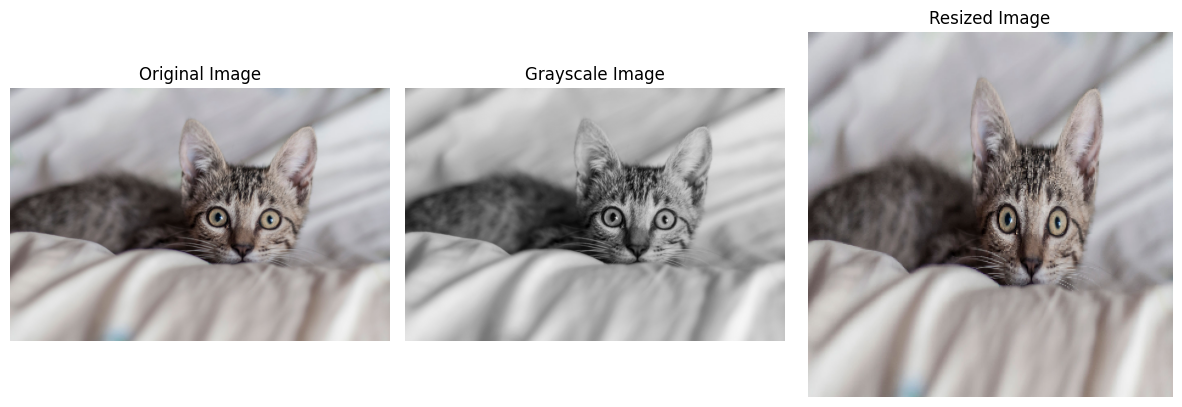

In [ ]:
# Part 8: Display Original, Grayscale, and Resized Images
plt.figure(figsize=(12,4))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Resized Image")
plt.imshow(resized_rgb)
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Part 9: Save Grayscale and Resized Images
cv2.imwrite('gray_sample.jpg', gray)
cv2.imwrite('resized_sample.jpg', resized)

True

In [ ]:
# Part 10: Confirmation Message
print("Images saved as 'gray_sample.jpg' and 'resized_sample.jpg'")


Images saved as 'gray_sample.jpg' and 'resized_sample.jpg'


In [ ]:
# Image Quality Enhancer for Social Media

In [ ]:
# uploald image
uploaded = files.upload()
img_path = next(iter(uploaded))
img = cv2.imread(img_path)

Saving cat.jpg to cat (2).jpg


In [ ]:
# auto contrast brightness
def auto_brightness_contrast(image, clip_hist_percent=25):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray],[0],None,[256],[0,256]).flatten()
    acc = np.cumsum(hist)
    clip = clip_hist_percent * (acc[-1] / 100.0) / 2.0
    min_gray = np.searchsorted(acc, clip)
    max_gray = np.searchsorted(acc, acc[-1] - clip)
    alpha = 255 / (max_gray - min_gray + 1e-5)
    beta = -min_gray * alpha
    return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

enhanced = auto_brightness_contrast(img)
resized = cv2.resize(enhanced, (1080, 1080))

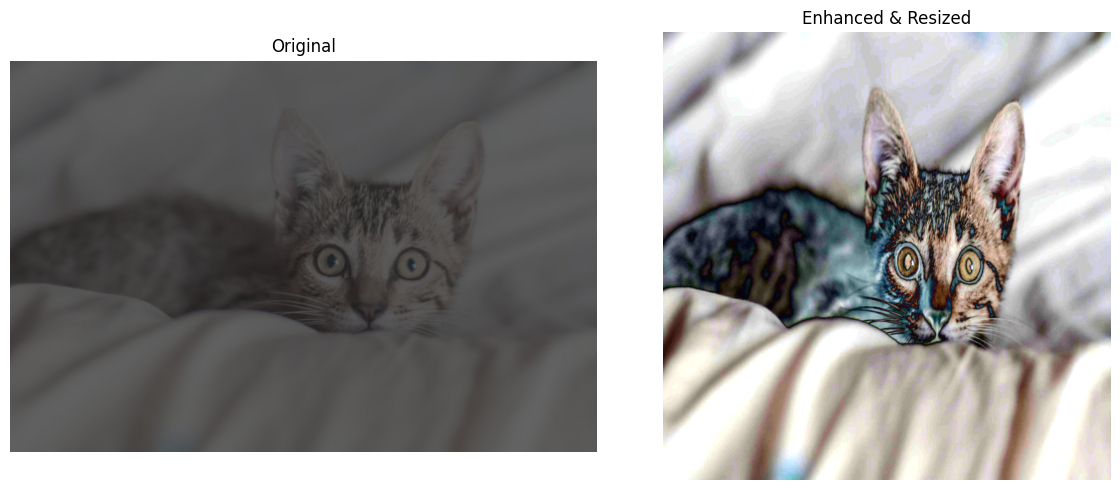

In [ ]:
# Show before and after
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[1].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
ax[1].set_title("Enhanced & Resized")
for a in ax: a.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Security Camera Grayscale Archiver

In [ ]:
# installing required library
import os

In [ ]:
print("Upload your CCTV image (e.g., .jpg, .png)...")
uploaded = files.upload()

Upload your CCTV image (e.g., .jpg, .png)...


Saving Sample-Image-captured-by-CCTV-camera.png to Sample-Image-captured-by-CCTV-camera.png


In [ ]:
input_image_path = list(uploaded.keys())[0]

In [ ]:
color_image = cv2.imread(input_image_path)

In [ ]:
if color_image is None:
  print("Error: Unable to read the image.")
else:
  gray_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

In [ ]:
output_image_path = 'cam_001_gray.jpg'
cv2.imwrite(output_image_path, gray_image)

True

In [ ]:
print(f"Grayscale image saved as: {output_image_path}")
files.download(output_image_path)

Grayscale image saved as: cam_001_gray.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Image Comparison for Duplicates

In [ ]:
# importing required library
from skimage.metrics import structural_similarity as ssim

In [ ]:
uploaded = files.upload()

Saving cam_001_gray.jpg to cam_001_gray (1).jpg
Saving Sample-Image-captured-by-CCTV-camera.png to Sample-Image-captured-by-CCTV-camera (1).png


In [ ]:
paths = list(uploaded.keys())

img1 = cv2.imread(paths[0])
img2 = cv2.imread(paths[1])
img1 = cv2.resize(img1, (500, 500))
img2 = cv2.resize(img2, (500, 500))
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

In [ ]:
# mse and ssim
mse = np.mean((gray1 - gray2) ** 2)
ssim_score, _ = ssim(gray1, gray2, full=True)
print(f"MSE: {mse:.2f}")
print(f"SSIM: {ssim_score:.4f}")

MSE: 0.79
SSIM: 0.9938


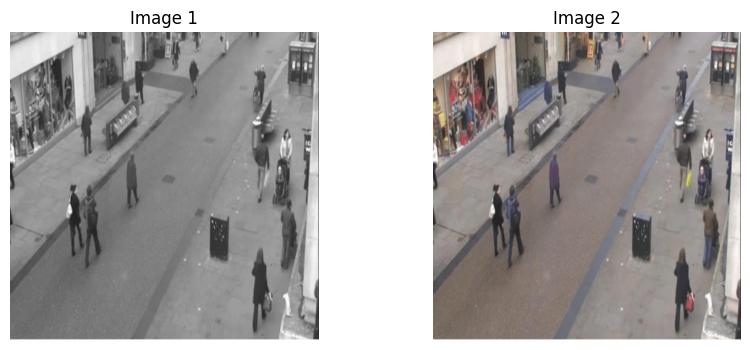

In [ ]:
# display both images
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
ax[0].set_title("Image 1")
ax[1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax[1].set_title("Image 2")
for a in ax: a.axis('off')
plt.show()

In [ ]:
#Color Filter for Object Detection

In [ ]:
#install open cv
!pip install opencv-python-headless --quiet

In [ ]:
#Upload an image
print("Upload an image to detect red objects...")
uploaded = files.upload()
input_image_path = list(uploaded.keys())[0]

Upload an image to detect red objects...


Saving Pomegranates_.jpg to Pomegranates_.jpg


In [ ]:
# convert bgr image to hsv color space
image = cv2.imread(input_image_path)
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

In [ ]:
#defining range for red color in hsv
lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

In [ ]:
mask1 = cv2.inRange(hsv_image, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv_image, lower_red2, upper_red2)
red_mask = mask1 + mask2

In [ ]:
red_detected = cv2.bitwise_and(image, image, mask=red_mask)

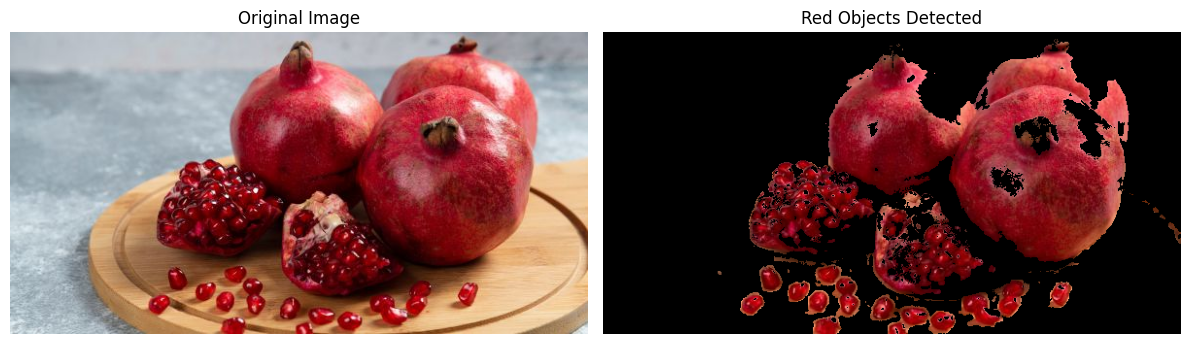

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(red_detected, cv2.COLOR_BGR2RGB))
plt.title("Red Objects Detected")
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Blurring License Plates for Privacy

In [ ]:
print("Upload your dashcam image:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)

Upload your dashcam image:


Saving Screenshot 2026-03-03 022639.png to Screenshot 2026-03-03 022639.png


In [ ]:
license_plate_rois = [
(100, 200, 150, 50), # Example 1
(400, 180, 160, 55) # Example 2
]

In [ ]:
height, width = image.shape[:2]

In [ ]:
for (x, y, w, h) in license_plate_rois:
  if x < 0 or y < 0 or x + w > width or y + h > height:
    print(f"Skipping ROI {(x, y, w, h)} because it's outside the image boundaries.")
    continue

Skipping ROI (400, 180, 160, 55) because it's outside the image boundaries.


In [ ]:
roi = image[y:y+h, x:x+w]
blurred_roi = cv2.GaussianBlur(roi, (51, 51), 0)
image[y:y+h, x:x+w] = blurred_roi

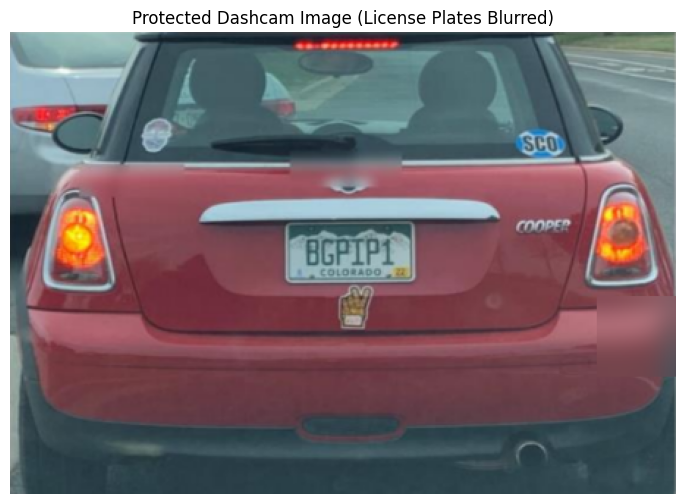

Saved protected image as protected_dashcam.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# display results
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Protected Dashcam Image (License Plates Blurred)")
plt.axis('off')
plt.show()
# Step 6: Save and download the protected image
output_filename = "protected_dashcam.jpg"
cv2.imwrite(output_filename, image)
print(f"Saved protected image as {output_filename}")
files.download(output_filename)